In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, max, min

In [ ]:
!apt-get install openjdk-11-jdk -y
!pip install pyspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libxcomposite1 libxt-dev libxtst6 libxxf86dga1
  openjdk-11-jdk-headless openjdk-11-jre openjdk-11-jre-headless
  session-migration x11-utils
Suggested packages:
  libxt-doc openjdk-11-demo openjdk-11-source visualvm libnss-mdns
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libxcomposite1 libxt-dev libxtst6 libxxf86dga1
  openjdk-11-jdk openjdk-11-jdk-headless openjdk-

In [ ]:
spark = SparkSession.builder \
    .appName("Sales Performance-Visualization") \
    .master("local[*]") \
    .getOrCreate()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sales_performance_dataset.csv to sales_performance_dataset.csv


In [ ]:
df = spark.read.csv("sales_performance_dataset.csv", header=True, inferSchema=True)

In [ ]:
pdf = df.toPandas()

In [ ]:
import matplotlib.pyplot as plt

# Total Monthly Sales by Department (Bar Chart)

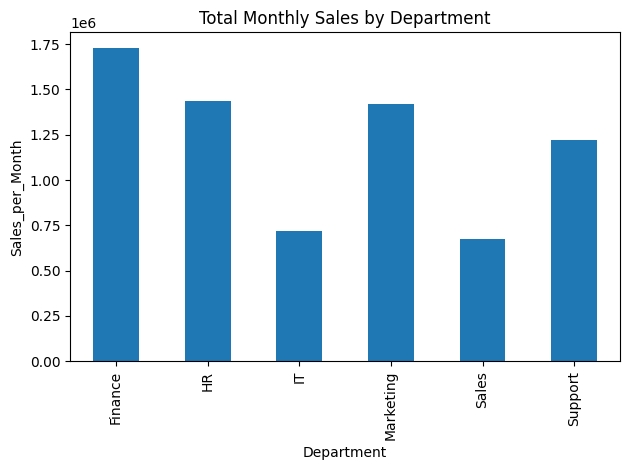

In [ ]:
dept_sales = pdf.groupby("Department")["Monthly_Sales"].sum()

plt.figure()
dept_sales.plot(kind='bar')
plt.title("Total Monthly Sales by Department")
plt.xlabel("Department")
plt.ylabel("Sales_per_Month")
plt.tight_layout()
plt.show()

# Experience vs Monthly Sales (Scatter Plot)

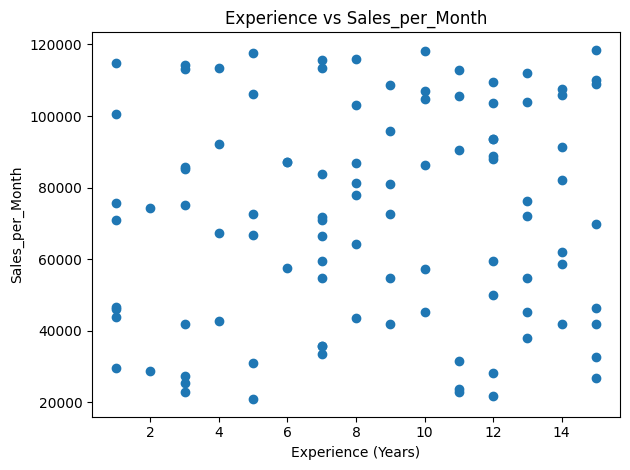

In [ ]:
plt.figure()
plt.scatter(pdf["Experience_Years"], pdf["Monthly_Sales"])
plt.title("Experience vs Sales_per_Month")
plt.xlabel("Experience (Years)")
plt.ylabel("Sales_per_Month")
plt.tight_layout()
plt.show()


# Customer Satisfaction Distribution (Histogram)

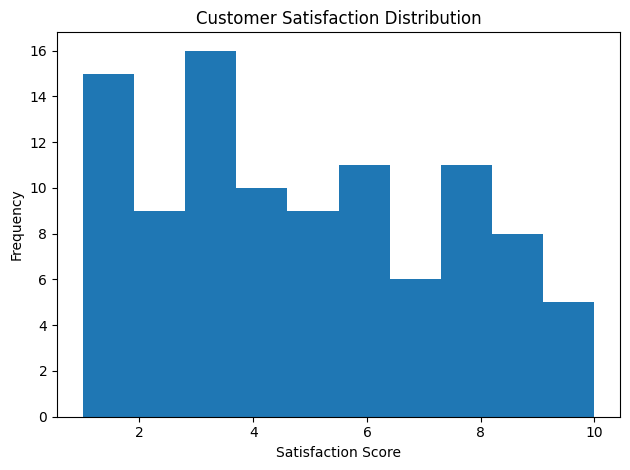

In [ ]:
plt.figure()
plt.hist(pdf["Customer_Satisfaction"], bins=10)
plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Monthly Sales Distribution by Department (Box Plot)

<Figure size 640x480 with 0 Axes>

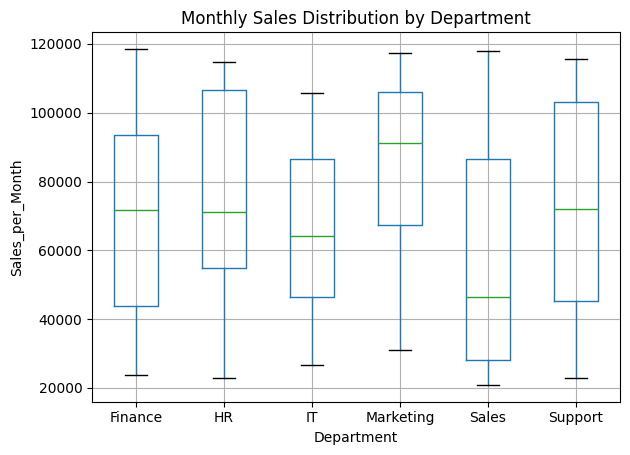

In [ ]:
plt.figure()
pdf.boxplot(column="Monthly_Sales", by="Department")
plt.title("Monthly Sales Distribution by Department")
plt.suptitle("")
plt.xlabel("Department")
plt.ylabel("Sales_per_Month")
plt.tight_layout()
plt.show()


# Monthly Sales by Department

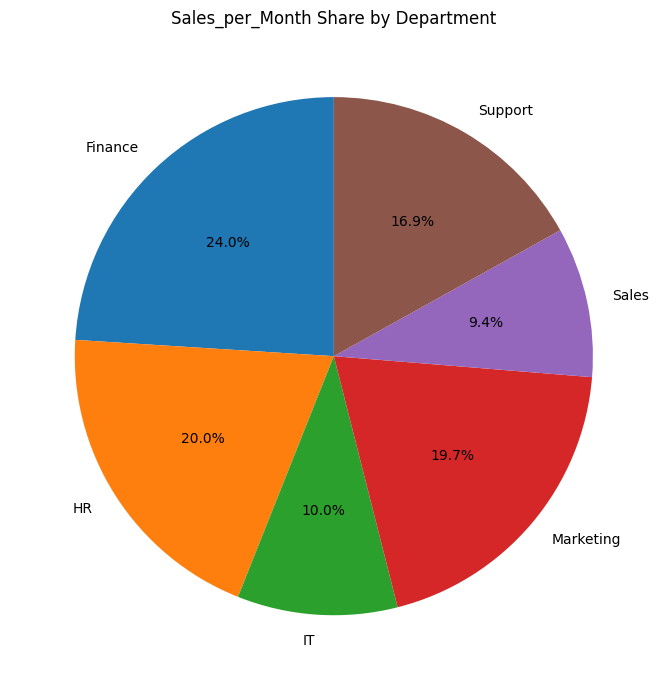

In [ ]:
dept_sales = pdf.groupby("Department")["Monthly_Sales"].sum()

plt.figure(figsize=(7,7))
plt.pie( dept_sales,labels=dept_sales.index,autopct="%1.1f%%",startangle=90)

plt.title("Sales_per_Month Share by Department")
plt.tight_layout()
plt.show()